# Superstore Sales Analysis

## Overview
This analysis explores 9,994 retail orders from a US superstore (2014–2017) to identify profitability drivers, the impact of discounting, regional performance gaps, and seasonal sales trends.

**Key questions explored:**
- Which product categories are most and least profitable?
- Are discounts helping or hurting profit?
- Which regions are underperforming?
- How do sales trend over time?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()




,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(f"Dataset size: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


Dataset size: 9994 rows and 21 columns

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## 1. Profitability by Category

First, let's look at which product categories generate the most profit.

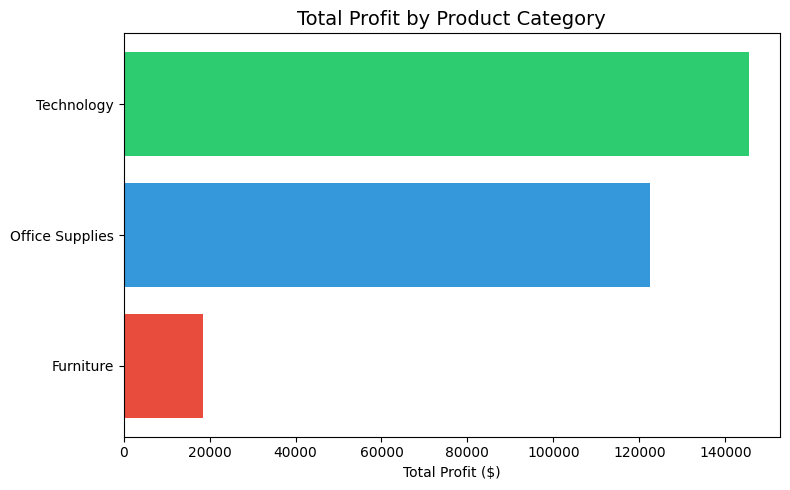

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [4]:
import matplotlib.pyplot as plt

category_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(category_profit.index, category_profit.values, color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Total Profit by Product Category', fontsize=14)
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()

print(category_profit)


**Finding:** Technology and Office Supplies have healthy profit margins (17%+), 
while Furniture earns only 2.49% despite having the highest sales volume. 
This suggests a pricing or cost issue in the Furniture category.

In [5]:
category_stats = df.groupby('Category')[['Sales', 'Profit']].sum()
category_stats['Profit Margin %'] = (category_stats['Profit'] / category_stats['Sales'] * 100).round(2)
print(category_stats)


                       Sales       Profit  Profit Margin %
Category                                                  
Furniture        741999.7953   18451.2728             2.49
Office Supplies  719047.0320  122490.8008            17.04
Technology       836154.0330  145454.9481            17.40


In [6]:
discount_profit = df.groupby('Category')[['Discount', 'Profit']].mean().round(3)
print(discount_profit)

                 Discount  Profit
Category                         
Furniture           0.174   8.699
Office Supplies     0.157  20.327
Technology          0.132  78.752


## 2. The Impact of Discounting on Profit

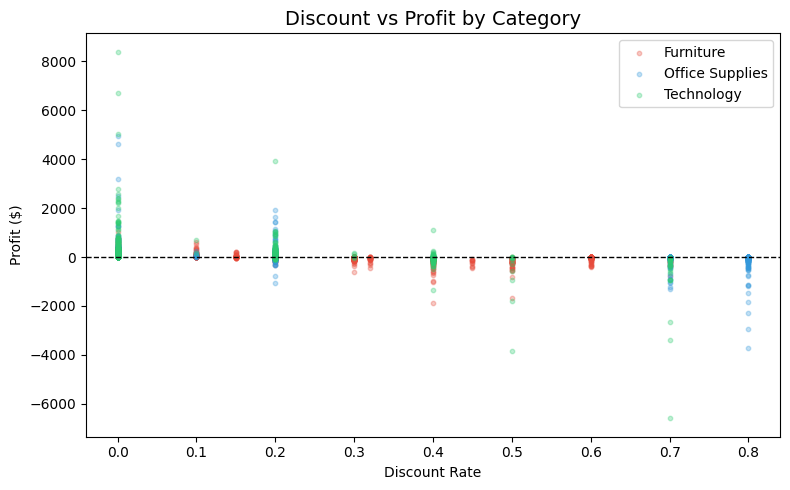

In [7]:
plt.figure(figsize=(8, 5))
colors = {'Furniture':'#e74c3c', 'Office Supplies':'#3498db', 'Technology':'#2ecc71'}

for category, group in df.groupby('Category'):
    plt.scatter(group['Discount'], group['Profit'], 
                alpha=0.3, label=category, color=colors[category], s=10)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Discount vs Profit by Category', fontsize=14)
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Finding:** Orders with no discount averaged $66.90 profit. 
Orders with discounts above 40% averaged -$106.71 — meaning the company 
loses $106 on every heavily discounted sale. High discounts are actively 
hurting profitability across all categories.

In [8]:
df['Discount Group'] = pd.cut(df['Discount'], 
                               bins=[-0.1, 0, 0.2, 0.4, 1.0], 
                               labels=['No Discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (41%+)'])

discount_analysis = df.groupby('Discount Group', observed=True)['Profit'].mean().round(2)
print(discount_analysis)

Discount Group
No Discount         66.90
Low (1-20%)         26.50
Medium (21-40%)    -77.86
High (41%+)       -106.71
Name: Profit, dtype: float64


## 3. Regional Performance

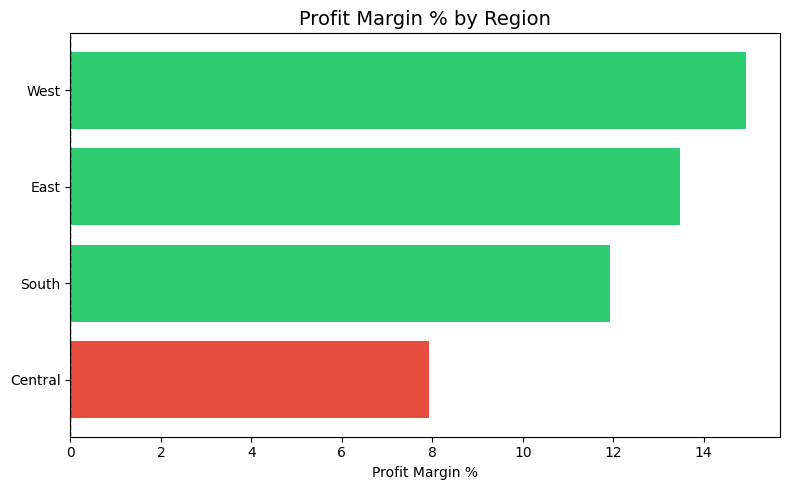

               Sales       Profit  Profit Margin %
Region                                            
Central  501239.8908   39706.3625             7.92
South    391721.9050   46749.4303            11.93
East     678781.2400   91522.7800            13.48
West     725457.8245  108418.4489            14.94


In [9]:
region_stats = df.groupby('Region')[['Sales', 'Profit']].sum()
region_stats['Profit Margin %'] = (region_stats['Profit'] / region_stats['Sales'] * 100).round(2)
region_stats = region_stats.sort_values('Profit Margin %')

plt.figure(figsize=(8, 5))
plt.barh(region_stats.index, region_stats['Profit Margin %'], 
         color=['#e74c3c' if x < 10 else '#2ecc71' for x in region_stats['Profit Margin %']])
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Profit Margin % by Region', fontsize=14)
plt.xlabel('Profit Margin %')
plt.tight_layout()
plt.show()

print(region_stats)

**Finding:** The Central region has the lowest profit margin compared to 
East, West, and South. Despite generating significant sales, Central 
is underperforming on profitability and may require a pricing or 
cost structure review.

## 4. Sales Trends Over Time

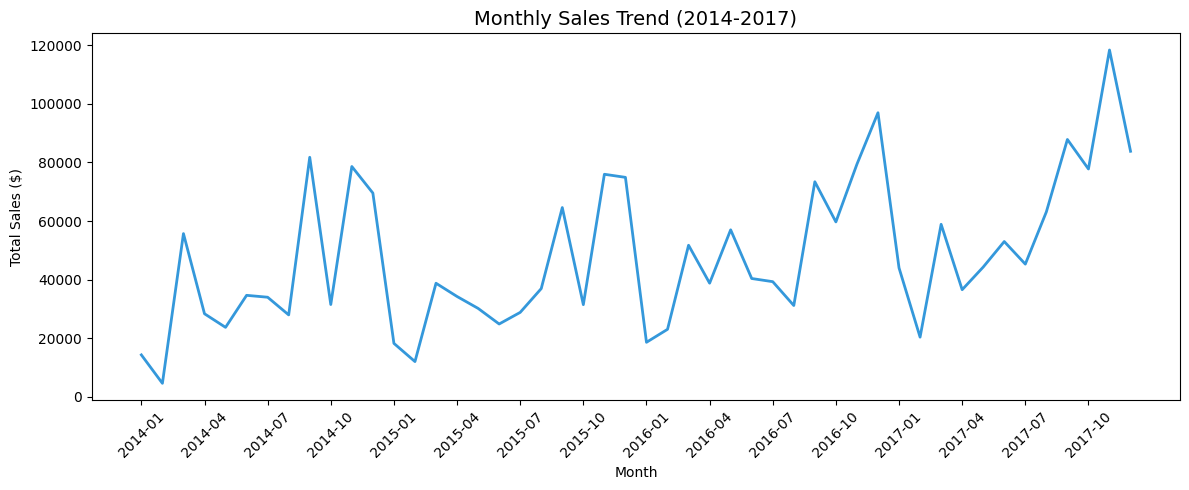

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, color='#3498db', linewidth=2)
plt.xticks(monthly_sales.index.astype(str)[::3], rotation=45)
plt.title('Monthly Sales Trend (2014-2017)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


## 4. Average sales per month 

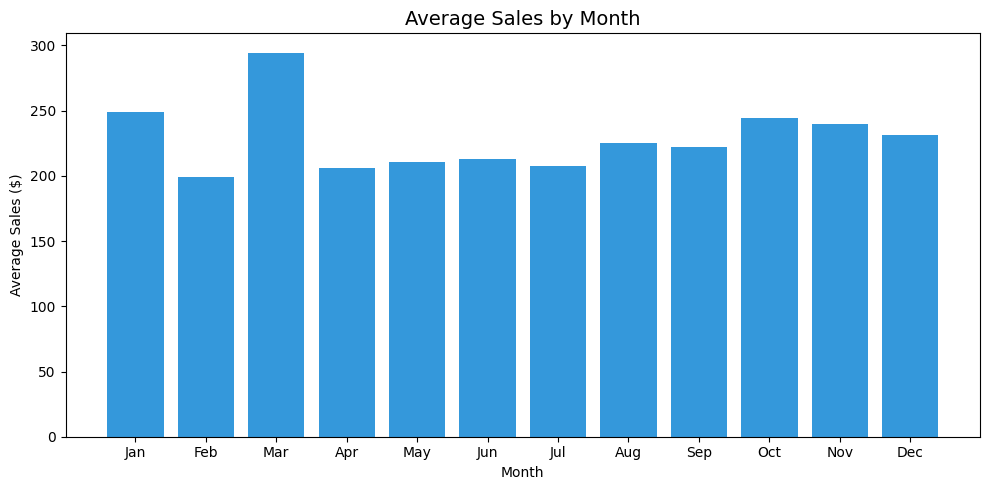

In [11]:
df['Month Name'] = df['Order Date'].dt.month
monthly_avg = df.groupby('Month Name')['Sales'].mean().round(2)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
plt.bar(month_labels, monthly_avg.values, color='#3498db')
plt.title('Average Sales by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Sales ($)')
plt.tight_layout()
plt.show()

*Finding:** Sales show consistent seasonal patterns year over year, 
with peaks in January, March, and October. This suggests corporate 
budget cycles drive purchases as much as consumer seasonality — 
useful for inventory planning and staffing decisions.